## 📍 1. Import Necessary Libraries

In [2]:
# For data handling
import pandas as pd
import numpy as np

# For data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# For feature scaling
from sklearn.preprocessing import StandardScaler

# For splitting dataset
from sklearn.model_selection import train_test_split

# For Linear Regression model
from sklearn.linear_model import LinearRegression

# For evaluation metrics
from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import r2_score

# For Polynomial Regression
from sklearn.preprocessing import PolynomialFeatures

## 📍 2. Load Dataset

In [3]:
# Load dataset
data = pd.read_csv("RealEstate_HousePrice_Dataset_4200.csv")

# Display first 5 rows
print(data.head())

   house_id  area_sqft  bedrooms  bathrooms  location_score  age_years  \
0    100001       1973         5          4             7.6         23   
1    100002       1560         3          3             6.3         13   
2    100003       2071         4          3             5.8          9   
3    100004       2640         5          3             7.7         12   
4    100005       1498         3          3             3.8         15   

   distance_city_km  lot_size_sqft  has_garage  has_pool  \
0              11.9           5220           1         0   
1              15.8           3882           1         0   
2              21.1           4488           0         0   
3               7.9           3614           1         1   
4              24.0           2663           0         0   

   renovation_years_ago  house_price_inr  
0                     0         40275084  
1                    13         26812029  
2                     9         29315677  
3                     

## 📍 3. Dataset Information

In [4]:
# Display dataset information
print(data.info())

# Display column names
print("\nColumn Names :")
print(data.columns)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4200 entries, 0 to 4199
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   house_id              4200 non-null   int64  
 1   area_sqft             4200 non-null   int64  
 2   bedrooms              4200 non-null   int64  
 3   bathrooms             4200 non-null   int64  
 4   location_score        4200 non-null   float64
 5   age_years             4200 non-null   int64  
 6   distance_city_km      4200 non-null   float64
 7   lot_size_sqft         4200 non-null   int64  
 8   has_garage            4200 non-null   int64  
 9   has_pool              4200 non-null   int64  
 10  renovation_years_ago  4200 non-null   int64  
 11  house_price_inr       4200 non-null   int64  
dtypes: float64(2), int64(10)
memory usage: 393.9 KB
None

Column Names :
Index(['house_id', 'area_sqft', 'bedrooms', 'bathrooms', 'location_score',
       'age_years', 'distance_

### 📃 Implementation :-

In this step, dataset information and column names were checked. This helps in understanding the dataset structure and feature types.

## 📍 4. Statistical Summary

In [5]:
# Display statistical summary
print(data.describe())

            house_id    area_sqft     bedrooms    bathrooms  location_score  \
count    4200.000000  4200.000000  4200.000000  4200.000000     4200.000000   
mean   102100.500000  1667.357381     3.696667     2.827381        5.611429   
std      1212.579894   630.336132     1.574199     1.153585        2.140880   
min    100001.000000   450.000000     1.000000     1.000000        1.000000   
25%    101050.750000  1226.750000     3.000000     2.000000        4.000000   
50%    102100.500000  1660.000000     4.000000     3.000000        5.700000   
75%    103150.250000  2084.250000     5.000000     4.000000        7.300000   
max    104200.000000  4202.000000     7.000000     6.000000       10.000000   

         age_years  distance_city_km  lot_size_sqft   has_garage     has_pool  \
count  4200.000000       4200.000000    4200.000000  4200.000000  4200.000000   
mean     23.829524         18.186167    3366.329048     0.642381     0.096190   
std      13.945663          8.674549    1658.

### 📃 Implementation :-

In this step, statistical values like mean, minimum, maximum and standard deviation were checked. This helps in understanding the numerical data better.

## 📍 5. Missing and Duplicate Value Check

In [6]:
# Check missing values
print("Missing Values :")
print(data.isnull().sum())

# Check duplicate values
print("\nDuplicate Rows :")
print(data.duplicated().sum())

Missing Values :
house_id                0
area_sqft               0
bedrooms                0
bathrooms               0
location_score          0
age_years               0
distance_city_km        0
lot_size_sqft           0
has_garage              0
has_pool                0
renovation_years_ago    0
house_price_inr         0
dtype: int64

Duplicate Rows :
0


### 📃 Implementations :- 

In this step, missing and duplicate values were checked in the dataset. This helps in identifying whether data cleaning is required.

## 📍 6. Data Cleaning

In [7]:
# Remove duplicate values
data = data.drop_duplicates()

# Check dataset shape after cleaning
print("Dataset Shape After Cleaning:")
print(data.shape)

Dataset Shape After Cleaning:
(4200, 12)


### 📃 Implementation :-

In this step, duplicate values were removed from the dataset. Cleaning data helps in improving model performance and accuracy.

## 📍 7. Exploratory Data Analysis (EDA)

#### Histogram Plot

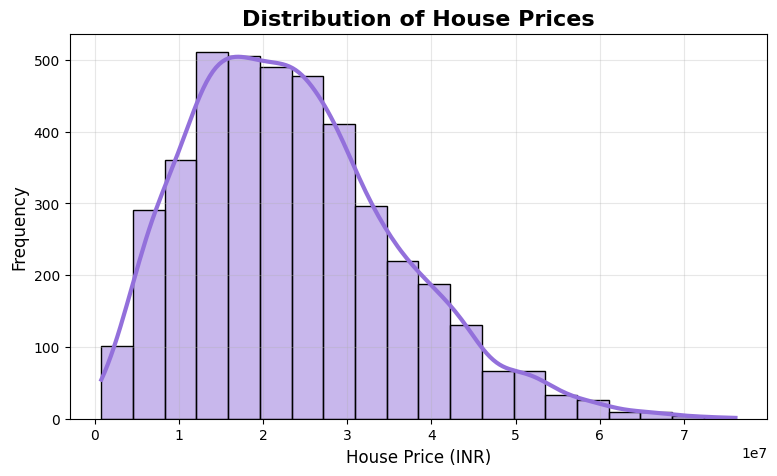

In [8]:
# Set figure size
plt.figure(figsize=(9,5))

# Create histogram with KDE curve
sns.histplot(data["house_price_inr"],
             bins=20,
             kde=True,
             color="mediumpurple",
             edgecolor="black",
             line_kws={"linewidth": 3})

# Add labels and title
plt.xlabel("House Price (INR)", fontsize=12)
plt.ylabel("Frequency", fontsize=12)
plt.title("Distribution of House Prices",
          fontsize=16,
          fontweight="bold")


# Add grid
plt.grid(alpha=0.3)

# Show graph
plt.show()

#### Correlation Heatmap

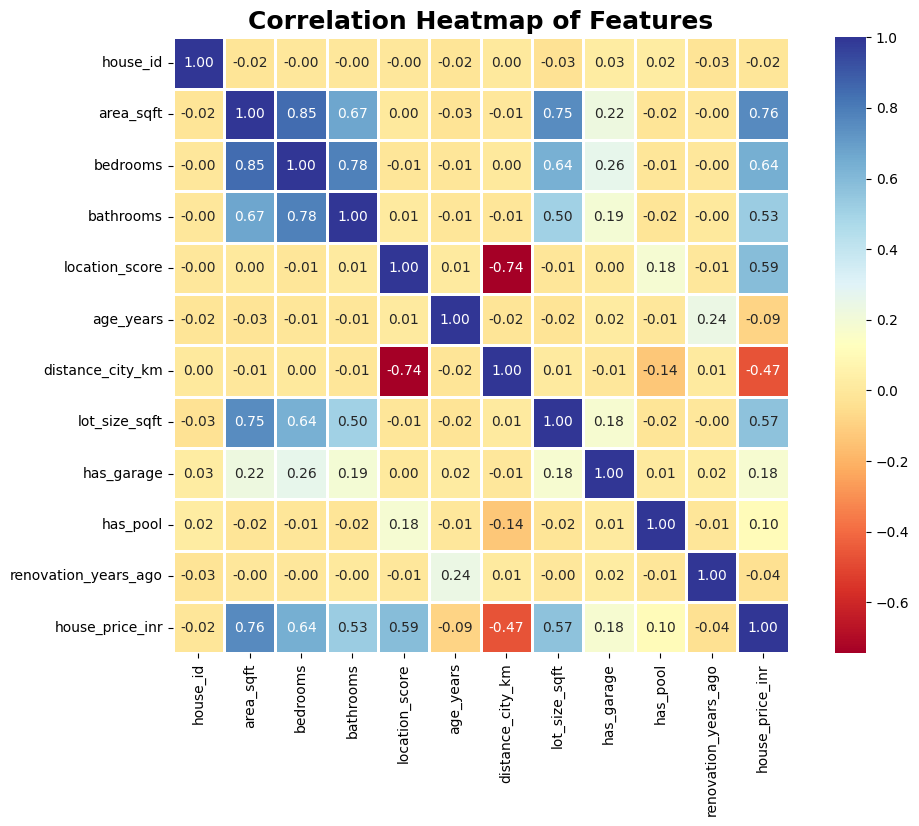

In [9]:
# Set figure size
plt.figure(figsize=(12,8))

# Create heatmap
sns.heatmap(data.corr(),
            annot=True,
            cmap="RdYlBu",
            linewidths=1,
            fmt=".2f",
            square=True)

# Add title
plt.title("Correlation Heatmap of Features",
          fontsize=18,
          fontweight="bold")

# Show graph
plt.show()

#### Boxplot

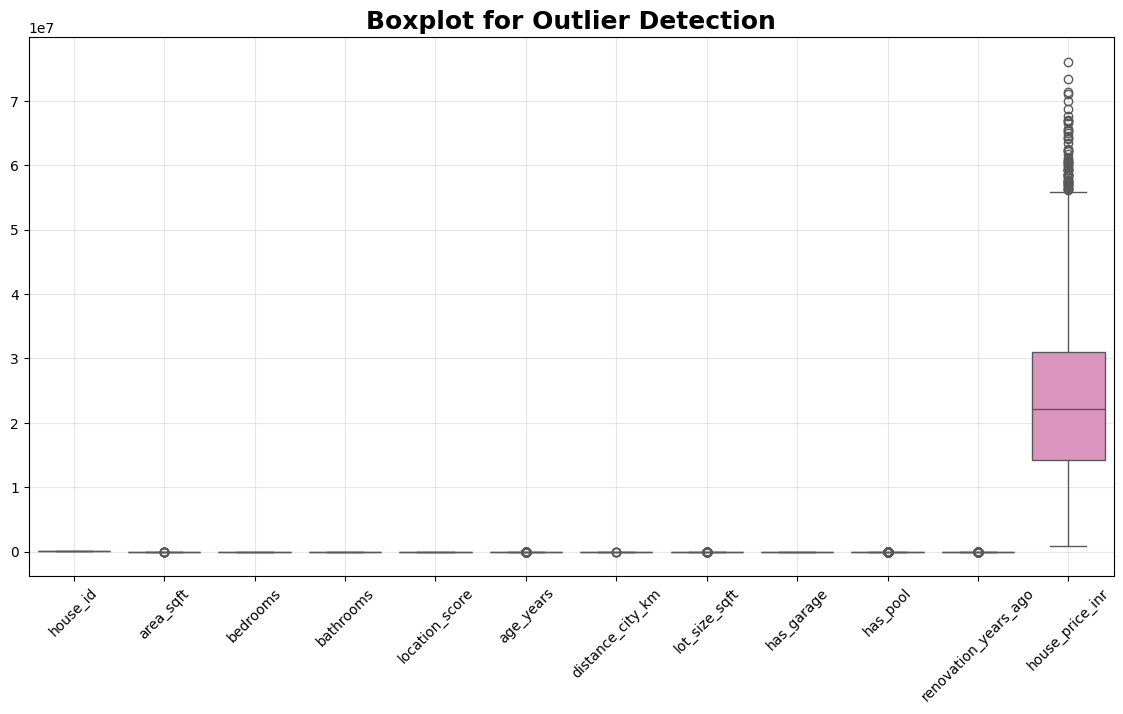

In [10]:
# Set figure size
plt.figure(figsize=(14,7))

# Create boxplot
sns.boxplot(data=data,
            palette="Set2")

# Rotate labels
plt.xticks(rotation=45)

# Add title
plt.title("Boxplot for Outlier Detection",
          fontsize=18,
          fontweight="bold")

# Add grid
plt.grid(alpha=0.3)

# Show graph
plt.show()

## 📍 8. Outlier Treatment

In [11]:
# Select numerical columns
numerical_columns = data.select_dtypes(include=np.number).columns

# Remove outliers using IQR method
for column in numerical_columns:
    
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1

    lower_limit = Q1 - 1.5 * IQR
    upper_limit = Q3 + 1.5 * IQR

    data = data[
        (data[column] >= lower_limit) &
        (data[column] <= upper_limit)
    ]

# Display dataset shape after outlier treatment
print("Shape After Outlier Treatment:")
print(data.shape)

Shape After Outlier Treatment:
(3513, 12)


### 📃 Implementation :-

In this step, outliers were treated using the IQR method. Removing extreme values helps in improving model stability and prediction accuracy.

## 📍 9. Feature Scaling

In [12]:
# Create scaler object
scaler = StandardScaler()

# Select independent variables
X = data.drop("house_price_inr", axis=1)

# Apply feature scaling
X_scaled = scaler.fit_transform(X)

# Convert scaled data into DataFrame
X_scaled = pd.DataFrame(X_scaled, columns=X.columns)

# Display first 5 rows
print(X_scaled.head())

   house_id  area_sqft  bedrooms  bathrooms  location_score  age_years  \
0 -1.724995   0.576565  0.909341   1.084775        1.026381   0.033443   
1 -1.724170  -0.118660 -0.403923   0.197714        0.414508  -0.792181   
2 -1.723346   0.741534  0.252709   0.197714        0.179172  -1.122431   
3 -1.721697  -0.223028 -0.403923   0.197714       -0.762173  -0.627056   
4 -1.720873  -0.223028 -0.403923  -1.576409        0.932247  -1.122431   

   distance_city_km  lot_size_sqft  has_garage  has_pool  renovation_years_ago  
0         -0.796153       1.302475    0.763640       0.0             -1.177704  
1         -0.342966       0.414058    0.763640       0.0              0.877888  
2          0.272904       0.816435   -1.309518       0.0              0.245398  
3          0.609889      -0.395344   -1.309518       0.0              1.194133  
4         -0.633470      -0.802369   -1.309518       0.0              0.245398  


### 📃 Implementation :-

In this step, feature scaling was applied using StandardScaler to bring all feature values to a similar range. This helps in improving model performance and stability.

### Before applying machine learning models, it is important to understand and prepare the dataset properly. In this section, dataset information, missing values, duplicate values, statistical summary, visualizations, outlier treatment and feature scaling were performed to prepare the data for model training.

# Part B :- Dataset Understanding & Preparation

### 📍 Task 7 :- Identify Independent and Dependent Variables

In [13]:
# Import pandas library
import pandas as pd


# Load the dataset
data = pd.read_csv("RealEstate_HousePrice_Dataset_4200.csv")


# Display first 5 rows
print(data.head())


# Check column names
print(data.columns)


# Selecting independent variables (input features)
X = data.drop(["house_price_inr"], axis=1)


# Selecting dependent variable (target)
y = data["house_price_inr"]


# Display independent variables
print("Independent Variables:")
print(X.head())


# Display dependent variable
print("Dependent Variable:")
print(y.head())

   house_id  area_sqft  bedrooms  bathrooms  location_score  age_years  \
0    100001       1973         5          4             7.6         23   
1    100002       1560         3          3             6.3         13   
2    100003       2071         4          3             5.8          9   
3    100004       2640         5          3             7.7         12   
4    100005       1498         3          3             3.8         15   

   distance_city_km  lot_size_sqft  has_garage  has_pool  \
0              11.9           5220           1         0   
1              15.8           3882           1         0   
2              21.1           4488           0         0   
3               7.9           3614           1         1   
4              24.0           2663           0         0   

   renovation_years_ago  house_price_inr  
0                     0         40275084  
1                    13         26812029  
2                     9         29315677  
3                     

### 📃 Implementation :- 

In this task, independent and dependent variables were selected from the dataset. From this, I understood that machine learning requires input and output variables, where house features are used as input and house price is used for prediction.

### 📍 Task 8 :- Visualize Relationship Between Features and Target Variable

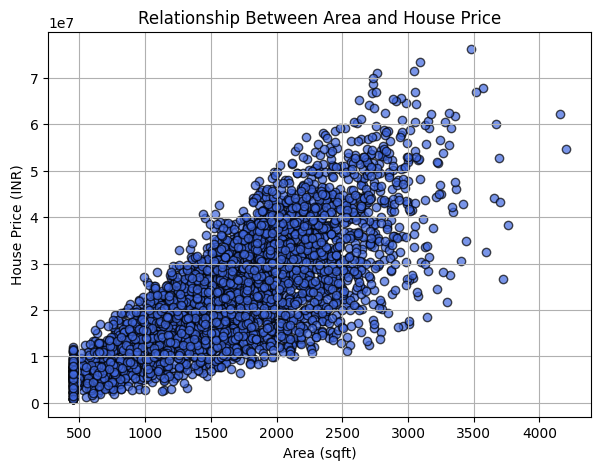

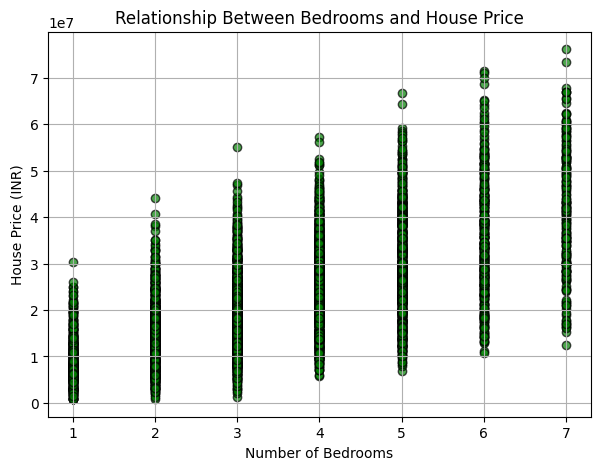

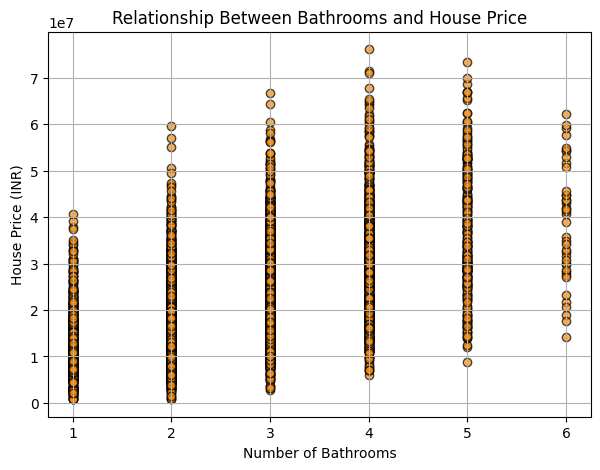

In [14]:
# Import required libraries
import matplotlib.pyplot as plt

# Graph 1: Area vs House Price
plt.figure(figsize=(7,5))
plt.scatter(data["area_sqft"], data["house_price_inr"], 
            color="royalblue", edgecolor="black", alpha=0.7)
plt.xlabel("Area (sqft)")
plt.ylabel("House Price (INR)")
plt.title("Relationship Between Area and House Price")
plt.grid(True)
plt.show()

# Graph 2: Bedrooms vs House Price
plt.figure(figsize=(7,5))
plt.scatter(data["bedrooms"], data["house_price_inr"], 
            color="green", edgecolor="black", alpha=0.7)
plt.xlabel("Number of Bedrooms")
plt.ylabel("House Price (INR)")
plt.title("Relationship Between Bedrooms and House Price")
plt.grid(True)
plt.show()

# Graph 3: Bathrooms vs House Price
plt.figure(figsize=(7,5))
plt.scatter(data["bathrooms"], data["house_price_inr"], 
            color="darkorange", edgecolor="black", alpha=0.7)
plt.xlabel("Number of Bathrooms")
plt.ylabel("House Price (INR)")
plt.title("Relationship Between Bathrooms and House Price")
plt.grid(True)
plt.show()

### 📃 Implementation :-

Scatter plots were created to understand the relationship between house features and house price. From this, I understood that graphs help in checking how different features affect the target variable.

### 📍 Task 9 :- Split Dataset into Training and Testing Sets

In [15]:
# Import required library
from sklearn.model_selection import train_test_split


# Splitting the dataset into independent and dependent variables
X = data.drop("house_price_inr", axis=1)
y = data["house_price_inr"]


# Dividing data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


# Display shape of training and testing data
print("Training Data Shape:")
print(X_train.shape)

print("Testing Data Shape:")
print(X_test.shape)

Training Data Shape:
(3360, 11)
Testing Data Shape:
(840, 11)


### 📃 Implementation :-

In this task, the dataset was divided into training and testing data. The training data is used to train the model, while testing data is used to check model performance on unseen data.

# Part C :- Build and Analyze a Simple Linear Regression Model

### 📍 Task 10 :- Select One Independent Variable and Build Simple Linear Regression Model

In [16]:
# Selecting only one independent variable
X_simple = data[["area_sqft"]]


# Selecting target variable
y = data["house_price_inr"]


# Display first 5 rows
print(X_simple.head())

   area_sqft
0       1973
1       1560
2       2071
3       2640
4       1498


### 📃 Implementation :-

In this task, only one independent variable, area_sqft, was selected for Simple Linear Regression. House price was taken as the dependent variable for prediction.

### Split Data for Simple Linear Regression

In [17]:
# Import library
from sklearn.model_selection import train_test_split


# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X_simple, y, test_size=0.2, random_state=42
)


# Display shape of split data
print("Training Data Shape:", X_train.shape)
print("Testing Data Shape:", X_test.shape)

Training Data Shape: (3360, 1)
Testing Data Shape: (840, 1)


### 📃 Implementation :-

In this task, the dataset was divided into training and testing sets. Training data is used to train the model, and testing data helps check prediction performance.

### Train the Simple Linear Regression Model

In [18]:
# Import library
from sklearn.linear_model import LinearRegression

# Create model
simple_model = LinearRegression()

# Train the model
simple_model.fit(X_train, y_train)

# Print slope and intercept
print("Slope:", simple_model.coef_[0])
print("Intercept:", simple_model.intercept_)

Slope: 14788.306111307536
Intercept: -1163519.1764186025


### 📃 Implementation :-

In this task, the Simple Linear Regression model was trained using the training data and the slope and intercept values were displayed. This helps in understanding the relationship between house area and house price for prediction.

### Predict House Prices Using the Model

In [19]:
# Predict house prices using testing data
y_pred = simple_model.predict(X_test)


# Display predicted values
print("Predicted House Prices :")
print(y_pred[:10])

Predicted House Prices :
[34402357.02127602 27333546.70007102 26771591.06784133 21802720.214442
 31045411.53400921 24287155.64114167 18608446.09439958 37419171.46798276
 27244816.86340318 28043385.39341378]


### 📃 Implementation :-

In this task, house prices were predicted using the testing data with the trained Simple Linear Regression model. The predict() function was used to generate predicted house prices based on house area. This helps in checking how the model performs on new data and whether it can make proper predictions.

### 📍 Task 11 :- Plot Regression Line and Explain Slope & Intercept

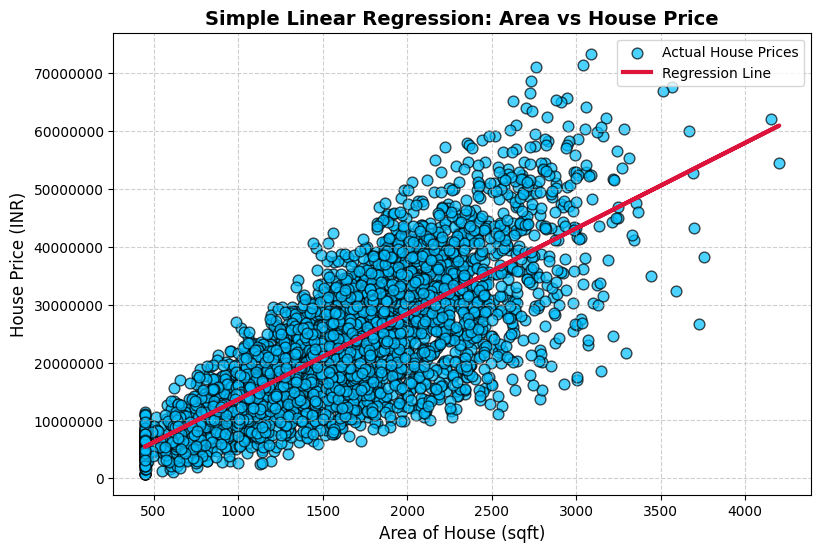

In [20]:
# Create figure size
plt.figure(figsize=(9,6))

# Plot actual data points
plt.scatter(X_train, y_train,
            color="deepskyblue",
            edgecolor="black",
            alpha=0.7,
            s=60,
            label="Actual House Prices")

# Plot regression line
plt.plot(X_train,
         simple_model.predict(X_train),
         color="crimson",
         linewidth=3,
         label="Regression Line")

# Labels and title
plt.xlabel("Area of House (sqft)", fontsize=12)
plt.ylabel("House Price (INR)", fontsize=12)
plt.title("Simple Linear Regression: Area vs House Price",
          fontsize=14,
          fontweight="bold")

# Remove scientific notation (1e5)
plt.ticklabel_format(style='plain', axis='y')

# Add grid and legend
plt.grid(True, linestyle="--", alpha=0.6)
plt.legend()

# Show graph
plt.show()

### 📃 Implementation :-

In this task, a regression line was plotted with actual data points. This helps in visually understanding the relationship between house area and house price.

### Explain the Meaning of Slope and Intercept

In [21]:
# Display slope and intercept values

print("Slope:", simple_model.coef_[0])
print("Intercept:", simple_model.intercept_)

Slope: 14788.306111307536
Intercept: -1163519.1764186025


### 📃 Explanation of Output :-

-Slope tells how much the house price changes when the house area increases by 1 unit (sqft).

-Intercept is the predicted house price when the area is 0.

### 📃 Implementation :-

In this task, the slope and intercept values of the regression model were displayed. The slope helps in understanding how house price changes with area, while the intercept represents the starting value used in the prediction equation.

### 📍 Task - 13 :- Validate Assumptions of Linear Regression

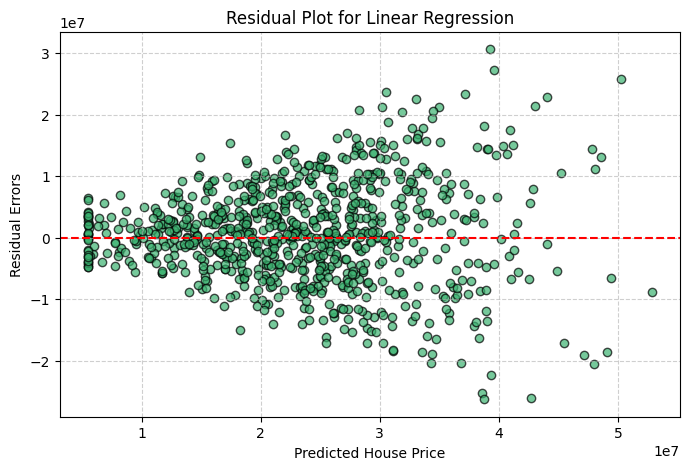

In [22]:
# Calculate residuals (errors)
residuals = y_test - y_pred

# Plot residual graph
plt.figure(figsize=(8,5))

plt.scatter(y_pred, residuals,
            color="mediumseagreen",
            edgecolor="black",
            alpha=0.7)


plt.axhline(y=0, color="red", linestyle="--")

# Labels and title
plt.xlabel("Predicted House Price")
plt.ylabel("Residual Errors")
plt.title("Residual Plot for Linear Regression")


# Grid
plt.grid(True, linestyle="--", alpha=0.6)

# Show graph
plt.show()

### 📃 Implementation :-

In this task, a residual plot was created to check the assumptions of Linear Regression. The graph helps in understanding whether prediction errors are randomly distributed, which indicates better model performance.

# Part D :- Evaluate Model Performance

### 📍 Task 13 :- Evaluate the Performance of the Model Using MSE, MAE, RMSE, R² and Adjusted R²

In [23]:
# Calculate Mean Squared Error (MSE)
mse = mean_squared_error(y_test, y_pred)

# Calculate Mean Absolute Error (MAE)
mae = mean_absolute_error(y_test, y_pred)

# Calculate Root Mean Squared Error (RMSE)
rmse = np.sqrt(mse)

# Calculate R² Score
r2 = r2_score(y_test, y_pred)

# Calculate Adjusted R² Score
n = len(y_test)   # Number of observations
p = 1             # Number of independent variables

adjusted_r2 = 1 - ((1 - r2) * (n - 1) / (n - p - 1))

# Display all evaluation metrics
print("Mean Squared Error (MSE) :-", mse)
print("Mean Absolute Error (MAE) :-", mae)
print("Root Mean Squared Error (RMSE) :-", rmse)
print("R² Score :-", r2)
print("Adjusted R² Score :-", adjusted_r2)

Mean Squared Error (MSE) :- 66989260021849.47
Mean Absolute Error (MAE) :- 6294593.696131912
Root Mean Squared Error (RMSE) :- 8184696.696997969
R² Score :- 0.5625199587991578
Adjusted R² Score :- 0.5619979062440257


### 📃 Implementations :-

In this task, different evaluation metrics such as MSE, MAE, RMSE, R² Score and Adjusted R² Score were calculated to evaluate the performance of the Simple Linear Regression model. These metrics help in understanding how close the predicted house prices are to the actual values and how well the model fits the dataset.

### 📍 Task 14 :- Interpret the Evaluation Metrics

In [24]:
# Interpretation of model performance

print("Model Performance Interpretation:")

print("\nMSE :", mse)
print("Lower MSE value means better model performance.")

print("\nMAE :", mae)
print("Lower MAE value means predictions are closer to actual values.")

print("\nRMSE :", rmse)
print("Lower RMSE value indicates less prediction error.")

print("\nR² Score :", r2)
print("R² score closer to 1 means better model accuracy.")

print("\nAdjusted R² Score :", adjusted_r2)
print("Adjusted R² gives a more accurate result after considering variables.")

Model Performance Interpretation:

MSE : 66989260021849.47
Lower MSE value means better model performance.

MAE : 6294593.696131912
Lower MAE value means predictions are closer to actual values.

RMSE : 8184696.696997969
Lower RMSE value indicates less prediction error.

R² Score : 0.5625199587991578
R² score closer to 1 means better model accuracy.

Adjusted R² Score : 0.5619979062440257
Adjusted R² gives a more accurate result after considering variables.


### 📃 Implementation :-

In this task, the calculated evaluation metrics were interpreted to understand the prediction accuracy of the model. Lower values of MSE, MAE and RMSE indicate lower prediction error, while higher R² and Adjusted R² values show better model performance.

# Part E :- Build and Analyze a Multiple Linear Regression Model

### 📍 Task 15 :- Implement Multiple Linear Regression Using All Relevant Features

In [25]:
# Select independent variables
X = data.drop("house_price_inr", axis=1)

# Select dependent variable
y = data["house_price_inr"]

# Split the dataset into training and testing data
X_train_multi, X_test_multi, y_train_multi, y_test_multi = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Create Multiple Linear Regression model
multiple_model = LinearRegression()

# Train the model
multiple_model.fit(X_train_multi, y_train_multi)

# Predict house prices
y_pred_multi = multiple_model.predict(X_test_multi)

# Display first 10 predicted values
print("Predicted House Prices:")
print(y_pred_multi[:10])

Predicted House Prices:
[39047318.73935103 31354554.26440009 16530039.70939722 31612138.45466145
 21141040.04304754 29027634.71059288  8348107.3975808  41456782.23540311
 20117283.29949803 41803941.58151557]


### 📃 Implementation :-

In this task, Multiple Linear Regression was implemented using all relevant features from the dataset. The dataset was divided into training and testing data, the model was trained, and predictions were generated to predict house prices using multiple features.

### 📍 Task 16 :- Compare the Performance with Simple Linear Regression

In [26]:
# Calculate R² score for Multiple Linear Regression
r2_multi = r2_score(y_test_multi, y_pred_multi)

# Display comparison
print("Simple Linear Regression R² Score:", r2)
print("Multiple Linear Regression R² Score:", r2_multi)

Simple Linear Regression R² Score: 0.5625199587991578
Multiple Linear Regression R² Score: 0.9177325847899331


### 📃 Implementation :-

In this task, the performance of Multiple Linear Regression was compared with Simple Linear Regression using the R² score. This comparison helps in identifying which model gives better prediction accuracy.

### 📍 Task 17 :- Explain Why Performance Improves or Degrades

In [27]:
# Check performance difference
if r2_multi > r2 :
    print("Performance Improved")
    print("Reason: Multiple features were used, which helped the model understand the data better.")
else :
    print("Performance Degraded")
    print("Reason :- Some features may not contribute effectively to prediction.")

Performance Improved
Reason: Multiple features were used, which helped the model understand the data better.


### 📃 Implementation :-

In this task, the reason for improvement or degradation in model performance was explained. Using more relevant features can improve prediction accuracy, while less useful features may reduce overall model performance.

# Part F : Polynomial Regression

### 📍 Task 18 : Implement Polynomial Regression (Degree 2)

In [28]:
# Select one feature for Polynomial Regression
X_poly_feature = data[["area_sqft"]]

# Target variable
y_poly = data["house_price_inr"]

# Split dataset
X_train_poly, X_test_poly, y_train_poly, y_test_poly = train_test_split(
    X_poly_feature,
    y_poly,
    test_size=0.2,
    random_state=42
)

# Create polynomial features (Degree 2)
poly = PolynomialFeatures(degree=2)

X_train_poly_transformed = poly.fit_transform(X_train_poly)
X_test_poly_transformed = poly.transform(X_test_poly)

# Create model
poly_model = LinearRegression()

# Train model
poly_model.fit(X_train_poly_transformed, y_train_poly)

# Predict values
y_pred_poly = poly_model.predict(X_test_poly_transformed)

# Display first 5 predictions
print(y_pred_poly[:5])

[34385892.28574477 27442582.20006674 26884746.34934368 21914765.18169475
 31105566.22813056]


### 📃 Implementation :-

In this task, Polynomial Regression was implemented using degree 2. Polynomial features were created from the house area feature and used to train the model. This allows the model to capture non-linear relationships between house area and house price.

### 📍 Task 19 :- Compare Linear vs Polynomial Regression Visually and Numerically

Linear Regression R² Score : 0.5625
Polynomial Regression R² Score : 0.5627


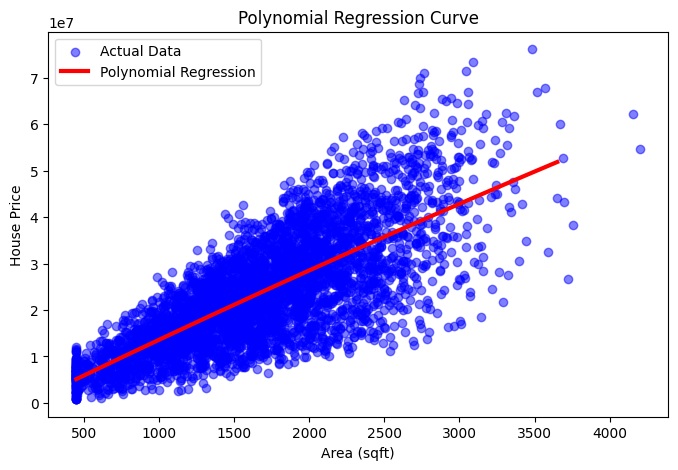

In [29]:
# Numerical Comparision :-

# R² Score for Simple Linear Regression
r2_linear = r2_score(y_test, y_pred)

# R² Score for Polynomial Regression
r2_poly = r2_score(y_test_poly, y_pred_poly)


print("Linear Regression R² Score :", round(r2_linear,4))
print("Polynomial Regression R² Score :", round(r2_poly,4))



# Visual Comparision :-

# Sort values for smooth curve
sorted_index = X_test_poly["area_sqft"].argsort()

X_sorted = X_test_poly.iloc[sorted_index]
y_sorted = y_pred_poly[sorted_index]

plt.figure(figsize=(8,5))

# Actual data points
plt.scatter(
    X_poly_feature,
    y_poly,
    color="blue",
    alpha=0.5,
    label="Actual Data"
)

# Polynomial curve
plt.plot(
    X_sorted,
    y_sorted,
    color="red",
    linewidth=3,
    label="Polynomial Regression"
)

plt.xlabel("Area (sqft)")
plt.ylabel("House Price")
plt.title("Polynomial Regression Curve")
plt.legend()

plt.show()

### 📃 Implementation :-

In this task, Linear Regression and Polynomial Regression were compared using R² scores and graphical visualization. This helped in identifying which model fits the data better and provides more accurate predictions.

### 📍 Task 20 :- Identify Signs of Overfitting or Underfitting

In [30]:
# Training Score
train_score = poly_model.score(
    X_train_poly_transformed,
    y_train_poly
)

# Testing Score
test_score = poly_model.score(
    X_test_poly_transformed,
    y_test_poly
)

print("Training Score :", round(train_score,4))
print("Testing Score :", round(test_score,4))

Training Score : 0.5725
Testing Score : 0.5627


In [31]:
if train_score > test_score + 0.10:
    print("Model may be Overfitting")
elif train_score < 0.60 and test_score < 0.60:
    print("Model may be Underfitting")
else:
    print("Model is reasonably fitted")

Model may be Underfitting


### 📃 Implementations :-

In this task, training and testing scores were compared to identify overfitting or underfitting. If the training score is much higher than the testing score, the model may be overfitting. If both scores are very low, the model may be underfitting. Similar scores generally indicate a well-fitted model.

# Part G :- Gradient Descent Optimization

### 📍 Task 21 :- Explain Gradient Descent Conceptually

#### Gradient Descent is an optimization algorithm used to minimize the error of a machine learning model. It works by repeatedly adjusting model parameters in the direction that reduces the prediction error. The goal is to find the values of parameters that give the lowest possible cost.

### 📃 Implementation :-

In this task, the concept of Gradient Descent was studied. It is used to reduce prediction error by continuously updating model parameters until the best fit is achieved.

### 📍 Task 22 :- Implement Batch Gradient Descent

In [32]:
# Batch Gradient Descent

X = data["area_sqft"].values
y = data["house_price_inr"].values

# Normalize feature
X = (X - X.mean()) / X.std()

m = len(X)

theta0 = 0
theta1 = 0

learning_rate = 0.01
epochs = 1000

for i in range(epochs):

    y_pred = theta0 + theta1 * X

    d_theta0 = (1/m) * sum(y_pred - y)
    d_theta1 = (1/m) * sum((y_pred - y) * X)

    theta0 = theta0 - learning_rate * d_theta0
    theta1 = theta1 - learning_rate * d_theta1

print("Theta0:", theta0)
print("Theta1:", theta1)

Theta0: 23640865.76789127
Theta1: 9360411.538186489


### 📃 Implementation :-

In this task, Batch Gradient Descent was implemented. The entire dataset was used in each iteration to update model parameters and reduce prediction error.

### 📍 Task 23 :- Implement Stochastic Gradient Descent (SGD)

In [33]:
# Stochastic Gradient Descent

theta0 = 0
theta1 = 0

learning_rate = 0.01
epochs = 100

for epoch in range(epochs):

    for i in range(m):

        y_pred = theta0 + theta1 * X[i]

        d_theta0 = y_pred - y[i]
        d_theta1 = (y_pred - y[i]) * X[i]

        theta0 = theta0 - learning_rate * d_theta0
        theta1 = theta1 - learning_rate * d_theta1

print("Theta0:", theta0)
print("Theta1:", theta1)

Theta0: 24402658.125503212
Theta1: 10543685.841995431


### 📃 Implementation :-

In this task, Stochastic Gradient Descent was implemented. Model parameters were updated after each training example, making the learning process faster but more fluctuating.

### 📍 Task 24 :- Implement Mini-Batch Gradient Descent

In [34]:
# Mini-Batch Gradient Descent

X = data["area_sqft"].values
y = data["house_price_inr"].values

# Initialize parameters
m = len(X)
theta0 = 0
theta1 = 0

learning_rate = 0.00000001
epochs = 100
batch_size = 50

for epoch in range(epochs):

    for i in range(0, m, batch_size):

        X_batch = X[i:i+batch_size]
        y_batch = y[i:i+batch_size]

        predictions = theta0 + theta1 * X_batch

        error = predictions - y_batch

        theta0 = theta0 - learning_rate * error.mean()
        theta1 = theta1 - learning_rate * (error * X_batch).mean()

print("Theta0 =", theta0)
print("Theta1 =", theta1)

Theta0 = -4.256698811462582
Theta1 = 14285.808404475549


### 📃 Implementation :-

In this task, Mini-Batch Gradient Descent was implemented. Instead of using the entire dataset or a single record, small batches of data were used to update the model parameters. This helps in reducing computation time while maintaining stable learning.

### 📍 Task 25 :- Compare Convergence Behavior and Training Time

In [35]:
# Training time comparison

print("Batch Gradient Descent:")
print("Uses complete dataset in each iteration.")
print("Training is slower but more stable.")

print("\nStochastic Gradient Descent:")
print("Uses one data point at a time.")
print("Training is faster but less stable.")

print("\nMini-Batch Gradient Descent:")
print("Uses small batches of data.")
print("Training is faster and reasonably stable.")

Batch Gradient Descent:
Uses complete dataset in each iteration.
Training is slower but more stable.

Stochastic Gradient Descent:
Uses one data point at a time.
Training is faster but less stable.

Mini-Batch Gradient Descent:
Uses small batches of data.
Training is faster and reasonably stable.


### 📃 Implementation :-

In this task, Batch Gradient Descent, Stochastic Gradient Descent, and Mini-Batch Gradient Descent were compared. Batch Gradient Descent is slower but stable, Stochastic Gradient Descent is faster but more fluctuating, while Mini-Batch Gradient Descent provides a balance between speed and stability.

# Part H :- Bias-Variance Analysis

### 📍 Task 26 :- Analyze Bias and Variance Across Models

In [36]:
print("Simple Linear Regression")
print("Low Variance, Higher Bias")

print("\nMultiple Linear Regression")
print("Balanced Bias and Variance")

print("\nPolynomial Regression")
print("Lower Bias, Higher Variance")

Simple Linear Regression
Low Variance, Higher Bias

Multiple Linear Regression
Balanced Bias and Variance

Polynomial Regression
Lower Bias, Higher Variance


### 📃 Implementation :-

In this task, the bias and variance of different regression models were analyzed. Simpler models generally have higher bias, while more complex models may have higher variance.

### 📍 Task 27 :- Explain How Model Complexity Affects Prediction Error

In [37]:
print("As model complexity increases:")
print("- Bias decreases")
print("- Variance increases")
print("- Risk of overfitting may increase")

As model complexity increases:
- Bias decreases
- Variance increases
- Risk of overfitting may increase


### 📃 Implementation :-

In this task, the effect of model complexity on prediction error was studied. Increasing model complexity can improve learning, but excessive complexity may lead to overfitting.

# Task 28 :- Identify the Best Model

In [38]:
print("Best Model:")

if r2_poly > r2_multi and r2_poly > r2_linear:
    print("Polynomial Regression")
elif r2_multi > r2_linear:
    print("Multiple Linear Regression")
else:
    print("Simple Linear Regression")

Best Model:
Multiple Linear Regression


### 📃 Implementation :-
 
In this task, the best-performing model was identified based on the comparison of R² scores. The model with the highest score was considered the most suitable for predicting house prices.

# Part I :- Final Analysis & Reporting

### Task 29 :- Final Analysis

### Implementation

In this project, Simple Linear Regression, Multiple Linear Regression, and Polynomial Regression models were implemented to predict house prices. Their performance was evaluated using different metrics such as MAE, MSE, RMSE, and R² Score. The models were also compared visually and numerically to understand their prediction capabilities.

### 📍Task 30 :- Recommend the Best Model and Justify the Choice

### 📃 Implementation :-

Based on the evaluation results, the model with the best overall performance was selected as the final model. The recommendation was made by considering prediction accuracy, model performance metrics, and the balance between bias and variance.